# MA429 Summative Project (Section 8)

- **Input Datasets**: "divvy_cleaned.parquet" (trip-level) and "station_hour_features.parquet" (station-hour panel)
- **Final Output**: Demand (Inflow/Outflow) prediction result
- **Section 8 (GAT-LSTM-DH)**: Two-layer **GAT** + Two-layer **LSTM** with  **dual output head** (regression + classification), which differs from Section 7’s single regression head. Other matches Section 7.

---
## 8 Demand Forecasting: GAT-LSTM-DH

### 8.0 Imports

Set `SOURCE = "drive"` on Colab or `SOURCE = "local"` locally.

In [2]:
import os
os.environ.setdefault('PYTORCH_ALLOC_CONF', 'expandable_segments:True')
import numpy as np
import pandas as pd
import json
from datetime import datetime
from typing import Dict, List, Optional, Tuple, Any
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Mount Google Drive (Colab)
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
SOURCE = "drive"  # "drive" on Colab, "local" locally

if SOURCE == "drive":
    divvy_path = "/content/drive/MyDrive/divvy_cleaned.parquet"
    station_hour_path = "/content/drive/MyDrive/station_hour_features.parquet"
else:
    divvy_path = "divvy_cleaned.parquet"
    station_hour_path = "station_hour_features.parquet"

# Load trip-level data (for building directed graph)
trips_df = pd.read_parquet(divvy_path)
print("divvy_cleaned.parquet shape:", trips_df.shape)
print("Trip columns (relevant):", [c for c in trips_df.columns if "station" in c.lower()])

# Load station-hour panel
df_panel = pd.read_parquet(station_hour_path)
print("station_hour_features.parquet shape (full):", df_panel.shape)

# Use first 30% of time span (same as Section 6)
_df_time = df_panel.sort_values(["date", "hour"]).reset_index(drop=True)
uniq_time = _df_time[["date", "hour"]].drop_duplicates().sort_values(["date", "hour"]).reset_index(drop=True)
T_total = len(uniq_time)
cutoff_T = max(1, int(T_total * 0.30))
uniq_time["_time_idx"] = range(T_total)
_df_time = _df_time.merge(uniq_time, on=["date", "hour"], how="left")
_df_time = _df_time[_df_time["_time_idx"] < cutoff_T].drop(columns=["_time_idx"]).reset_index(drop=True)
df_panel = _df_time
print("Using first 30%% of time steps: %d/%d" % (cutoff_T, T_total))
print("Subsampled date range: %s to %s" % (df_panel["date"].min(), df_panel["date"].max()))
print("Panel shape (time-subsampled 30%%):", df_panel.shape)

divvy_cleaned.parquet shape: (6236970, 18)
Trip columns (relevant): ['start_station_name', 'start_station_id', 'end_station_name', 'end_station_id']
station_hour_features.parquet shape (full): (21132864, 53)
Using first 30% of time steps: 3283/10944
Subsampled date range: 2024-01-01 to 2024-05-16
Panel shape (time-subsampled 30%%): (6339473, 53)


### 8.1 Build directed graph from trip data and sparsify

From **divvy_cleaned.parquet**, build directed arcs: each trip gives an edge from `start_station_id` to `end_station_id`. Aggregate edge counts, then **sparsify** by keeping **top-k in-edges and top-k out-edges per node** (by count), so each node retains both "who sends to me" and "where I send" structure. Restrict nodes to stations present in the panel.

In [4]:
# Stations that appear in the (time-subsampled) panel
panel_stations = set(df_panel["station_id"].astype(str).str.strip().unique())
# Filter trips: both endpoints must be valid
trips_clean = trips_df.dropna(subset=["start_station_id", "end_station_id"]).copy()
trips_clean["start_station_id"] = trips_clean["start_station_id"].astype(str).str.strip()
trips_clean["end_station_id"] = trips_clean["end_station_id"].astype(str).str.strip()
trips_clean = trips_clean[
    trips_clean["start_station_id"].str.lower() != "unknown"
].copy()
trips_clean = trips_clean[
    trips_clean["end_station_id"].str.lower() != "unknown"
].copy()
trips_clean = trips_clean[
    trips_clean["start_station_id"].isin(panel_stations)
    & trips_clean["end_station_id"].isin(panel_stations)
].copy()

train_end_date = df_panel["date"].sort_values().unique()[int(len(df_panel["date"].unique()) * 0.70)]
trips_clean = trips_clean[trips_clean["started_at"].dt.date.astype(str) < str(train_end_date)]

# Directed edge counts: (from_station, to_station) -> count
edge_counts = (
    trips_clean.groupby(["start_station_id", "end_station_id"])
    .size()
    .reset_index(name="count")
)
print("Unique directed edges (before sparsify):", len(edge_counts))

# Sparsify: keep top TOP_K in-edges and top TOP_K out-edges per node (by count)
TOP_K_EDGES = 50  # max in-edges and max out-edges per node after sparsification
edge_counts_sorted = edge_counts.sort_values("count", ascending=False)
sparse_in = []
for to_station, grp in edge_counts_sorted.groupby("end_station_id"):
    sparse_in.append(grp.head(TOP_K_EDGES))
in_edges = pd.concat(sparse_in, ignore_index=True)
sparse_out = []
for from_station, grp in edge_counts_sorted.groupby("start_station_id"):
    sparse_out.append(grp.head(TOP_K_EDGES))
out_edges = pd.concat(sparse_out, ignore_index=True)
edge_counts = pd.concat([in_edges, out_edges], ignore_index=True).drop_duplicates(subset=["start_station_id", "end_station_id"])
print("Unique directed edges (after sparsify, top-%d in + top-%d out per node):" % (TOP_K_EDGES, TOP_K_EDGES), len(edge_counts))

# Station index: consistent ordering with panel
station_order = sorted(panel_stations)
station_to_idx = {s: i for i, s in enumerate(station_order)}
N = len(station_order)

# COO edge_index: (2, E) with indices in [0, N-1]; row0 = source, row1 = target
edge_index = np.array([
    edge_counts["start_station_id"].map(station_to_idx).values,
    edge_counts["end_station_id"].map(station_to_idx).values,
], dtype=np.int64)
# Remove any edge that didn't map (safety)
valid = (edge_index[0] >= 0) & (edge_index[0] < N) & (edge_index[1] >= 0) & (edge_index[1] < N)
edge_index = edge_index[:, valid]
# Add self-loops so every node attends to itself during GAT aggregation
self_loop_src = np.arange(N, dtype=np.int64)
self_loop_idx = np.stack([self_loop_src, self_loop_src], axis=0)  # (2, N)
edge_index = np.concatenate([edge_index, self_loop_idx], axis=1)
print("Edge index with self-loops:", edge_index.shape)
# Deduplicate edges (self-loops may overlap with existing edges)
edge_index = np.unique(edge_index, axis=1)
print("Bidirectional edge index:", edge_index.shape)
print("Graph: N = %d nodes, E = %d edges" % (N, edge_index.shape[1]))
# Align log1p(trip count) to each edge; synthetic edges get 0
count_lookup = edge_counts.set_index(["start_station_id", "end_station_id"])["count"].to_dict()
station_order_arr = np.array(station_order)
edge_counts_arr = np.array([
    count_lookup.get(
        (station_order_arr[edge_index[0, i]], station_order_arr[edge_index[1, i]]), 0
    )
    for i in range(edge_index.shape[1])
], dtype=np.float32)
edge_feats = np.log1p(edge_counts_arr).reshape(-1, 1)  # (E, 1)
edge_feat_dim = edge_feats.shape[1]
print("edge_feats shape:", edge_feats.shape)

Unique directed edges (before sparsify): 73554
Unique directed edges (after sparsify, top-50 in + top-50 out per node): 38148
Edge index with self-loops: (2, 40078)
Bidirectional edge index: (2, 39251)
Graph: N = 1930 nodes, E = 39251 edges
edge_feats shape: (39251, 1)


### 8.2 Config and feature set

Single-step targets, full feature set A (base + heterogeneity), temporal split 70% / 15% / 15%, sequence length, and GAT+LSTM (improved) hyperparameters.

In [5]:
DEFAULT_TARGETS = ["target_outflow_t1", "target_inflow_t1"]
RUN_FEATURE_SET = "base_all_heterogeneity"
SPLIT_TRAIN_RATIO = 0.70
SPLIT_VAL_RATIO = 0.15
SPLIT_TEST_RATIO = 0.15
assert abs(SPLIT_TRAIN_RATIO + SPLIT_VAL_RATIO + SPLIT_TEST_RATIO - 1.0) < 1e-9

BASE_FLOW = ["outflow", "inflow"]
BASE_TIME = ["hour", "day_of_week", "is_weekend", "month", "sin_hour", "cos_hour"]
BASE_STATION = ["lat", "lng", "historical_mean_outflow", "historical_mean_inflow"]
HETEROGENEITY_MEMBER_CASUAL = ["member_ratio", "casual_ratio"]
HETEROGENEITY_CLUSTER = [f"cluster_{i}_ratio" for i in range(9)]
HETEROGENEITY_ALL = HETEROGENEITY_MEMBER_CASUAL + HETEROGENEITY_CLUSTER

def get_feature_columns(all_columns: List[str]) -> List[str]:
    base = [c for c in (BASE_FLOW + BASE_TIME + BASE_STATION + HETEROGENEITY_ALL) if c in all_columns]
    return base

DEFAULT_SEQ_LEN = 24
DEFAULT_GAT_LSTM_CONFIG = {
    "gat_heads": 4,
    "gat_hidden": 32,  
    "lstm_hidden": 128,
    "lstm_layers": 2,
    "dropout": 0.2,
    "epochs": 50,
    "times_per_batch": 32,
    "learning_rate": 0.001,
    "early_stopping_patience": 15,
    "clf_loss_weight": 0.3,   # alpha: weight for BCE classification loss; (1-alpha) for regression MSE
}

if "SOURCE" in dir() and SOURCE == "drive":
    RESULTS_DIR = "/content/drive/MyDrive/section7_results_two stage"
else:
    RESULTS_DIR = "section7_results_two stage"
os.makedirs(RESULTS_DIR, exist_ok=True)
LOG_DIR = os.path.join(RESULTS_DIR, "logs")
CONFIG_DIR = os.path.join(RESULTS_DIR, "configs")
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(CONFIG_DIR, exist_ok=True)

### 8.3 Temporal split and evaluation metrics

Same as Section 5/6/7: split by time (no shuffle); MAE, RMSE, WAPE, R².

In [6]:
def temporal_train_val_test_split(
    df: pd.DataFrame,
    train_ratio: float = SPLIT_TRAIN_RATIO,
    val_ratio: float = SPLIT_VAL_RATIO,
    test_ratio: float = SPLIT_TEST_RATIO,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9
    n = len(df)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train_df = df.iloc[:n_train]
    val_df = df.iloc[n_train : n_train + n_val]
    test_df = df.iloc[n_train + n_val :]
    return train_df, val_df, test_df

def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
def wape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    s_abs_diff = np.sum(np.abs(y_true - y_pred))
    s_abs_true = np.sum(np.abs(y_true)) + eps
    return float(s_abs_diff / s_abs_true)
def r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot < 1e-12:
        return 0.0
    return float(1.0 - ss_res / ss_tot)

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return {"MAE": mae(y_true, y_pred), "RMSE": rmse(y_true, y_pred), "WAPE": wape(y_true, y_pred), "R2": r2(y_true, y_pred)}

def append_result(results_list: List[Dict], model_name: str, target: str, feature_set: str, split: str, metrics: Dict[str, float], extra: Optional[Dict] = None) -> None:
    row = {"model": model_name, "target": target, "feature_set": feature_set, "split": split, **metrics}
    if extra:
        row.update(extra)
    results_list.append(row)

### 8.4 Build (T, N, F) panel and time splits

Reshape the station-hour panel into a 3D array: for each time index we have (N, F). Align by (date, hour) and station_id using the same `station_order` as the graph.

In [7]:
feature_cols = get_feature_columns(list(df_panel.columns))
# Ensure we have target columns
for t in DEFAULT_TARGETS:
    if t not in df_panel.columns:
        raise KeyError("Panel missing target column: %s" % t)

# Build time index (date, hour) -> _time_idx (vectorized)
df_panel = df_panel.sort_values(["date", "hour", "station_id"]).reset_index(drop=True)
uniq_time_panel = df_panel[["date", "hour"]].drop_duplicates().sort_values(["date", "hour"]).reset_index(drop=True)
T_panel = len(uniq_time_panel)
uniq_time_panel["_time_idx"] = np.arange(T_panel, dtype=np.int64)
df_panel = df_panel.merge(uniq_time_panel, on=["date", "hour"], how="left")

# Build station index (station_id -> _station_idx) (vectorized)
_station_idx = df_panel["station_id"].astype(str).str.strip().map(station_to_idx)
_df_idxed = df_panel.assign(_station_idx=_station_idx)
_df_idxed = _df_idxed.dropna(subset=["_station_idx", "_time_idx"]).copy()
_df_idxed["_station_idx"] = _df_idxed["_station_idx"].astype(np.int64)
_df_idxed["_time_idx"] = _df_idxed["_time_idx"].astype(np.int64)

# Safety: ensure unique (time_idx, station_idx) pairs
_dups = _df_idxed.duplicated(subset=["_time_idx", "_station_idx"], keep=False)
if _dups.any():
    # If duplicates exist, keep last (should not happen in a well-formed panel)
    _df_idxed = _df_idxed.sort_values(["_time_idx", "_station_idx"]).drop_duplicates(subset=["_time_idx", "_station_idx"], keep="last")

# Allocate and fill X_panel_3d in one shot using integer indexing
n_features = len(feature_cols)
X_panel_3d = np.zeros((T_panel, N, n_features), dtype=np.float32)

ti = _df_idxed["_time_idx"].to_numpy(dtype=np.int64)
si = _df_idxed["_station_idx"].to_numpy(dtype=np.int64)
feat_vals = _df_idxed[feature_cols].to_numpy(dtype=np.float32, copy=False)
X_panel_3d[ti, si, :] = feat_vals
# Z-score normalise X_panel_3d using training-set statistics only. Targets kept on original count scale so training loss is directly comparable to MAE/RMSE/WAPE/R².
t_train_idx = int(T_panel * SPLIT_TRAIN_RATIO)
train_mean = X_panel_3d[:t_train_idx].mean(axis=(0, 1), keepdims=True)  # shape (1, 1, F)
train_std  = X_panel_3d[:t_train_idx].std(axis=(0, 1),  keepdims=True) + 1e-8
X_panel_3d = (X_panel_3d - train_mean) / train_std
print("X_panel_3d normalised — train mean≈0, std≈1")

print("Panel 3D shape (T, N, F):", X_panel_3d.shape)

# Target arrays (T, N) for each target (vectorized)
target_arrays = {}
for tcol in DEFAULT_TARGETS:
    arr = np.zeros((T_panel, N), dtype=np.float32)
    y = _df_idxed[tcol].to_numpy(dtype=np.float32, copy=False)
    arr[ti, si] = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
    target_arrays[tcol] = arr

# Binary targets: 1 if flow > 0, 0 otherwise (for classification head)
binary_target_arrays = {}
for tcol in DEFAULT_TARGETS:
    binary_target_arrays[tcol] = (target_arrays[tcol] > 0).astype(np.float32)

# Log zero-rate statistics for reference
for tcol in DEFAULT_TARGETS:
    t_train_end = int(T_panel * SPLIT_TRAIN_RATIO)
    zero_rate = 1.0 - binary_target_arrays[tcol][:t_train_end].mean()
    print(f"{tcol} — training zero rate: {zero_rate:.3f}")

X_panel_3d normalised — train mean≈0, std≈1
Panel 3D shape (T, N, F): (3283, 1930, 23)
target_outflow_t1 — training zero rate: 0.934
target_inflow_t1 — training zero rate: 0.935


### 8.5  GAT-LSTM-DH model

**Output head change**: Section 7 outputs only one regression scalar per node and trains with a pure MSE objective. Section 8 replaces this with a **dual output head** that produces both (i) a regression value for flow count and (ii) a classification logit for `P(flow > 0)`.

$$
z_i\in\mathbb{R},\qquad p_i=\sigma(z_i)\in(0,1),
$$

where $z_i$ is the classification logit and $p_i$ is the predicted probability of non-zero demand.

**Joint training (regression+classification)**: for each node $i$, define

$$
y_{b,i}=\mathbf{1}[y_i>0].
$$

With regression prediction $\hat{y}$ and classification logit $z$, the joint objective is

$$
\mathcal{L} = (1-\alpha)\,\mathcal{L}_{\text{reg}} + \alpha\,\mathcal{L}_{\text{clf}},
$$

where

$$
\mathcal{L}_{\text{reg}} = \frac{1}{|\Omega_+|}\sum_{i\in\Omega_+}\mathrm{MSE}(\hat{y}_i,y_i),\quad \Omega_+=\{i\mid y_i>0\},
$$

$$
\mathcal{L}_{\text{clf}} = \frac{1}{N}\sum_{i=1}^{N}\mathrm{BCEWithLogits}(z_i,y_{b,i}).
$$

**Gating at inference**: convert the classification logit into probability $p_i=\sigma(z_i)$ and gate the final prediction by

$$
\hat{y}^{\text{final}}_i = p_i\cdot \max(\hat{y}_i,0).
$$


In [8]:
class GATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, n_heads=4, dropout=0.0, edge_feat_dim=0):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = out_dim // n_heads
        assert self.head_dim * n_heads == out_dim
        self.norm_in = nn.LayerNorm(in_dim)
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.a = nn.Parameter(torch.empty(n_heads, 2 * self.head_dim))
        self.leaky = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.a)
        # per-head bias from edge features (trip strength etc.)
        self.use_edge_feats = edge_feat_dim > 0
        if self.use_edge_feats:
            self.W_edge = nn.Linear(edge_feat_dim, n_heads, bias=True)

    def forward(self, x, edge_index, edge_feats=None):
        # x: (N, in_dim)  edge_index: (2, E)  edge_feats: (E, edge_feat_dim) or None
        N = x.size(0)
        src, tgt = edge_index[0], edge_index[1]

        x = self.norm_in(x)
        h = self.W(x).view(N, self.n_heads, self.head_dim)
        h_src = h[src]
        h_tgt = h[tgt]

        e = self.leaky(
            (torch.cat([h_tgt, h_src], dim=-1) * self.a.unsqueeze(0)).sum(-1)
        )  # (E, H)
        if self.use_edge_feats and edge_feats is not None:
            e = e + self.W_edge(edge_feats)  # bias attention by edge attributes

        e_max = torch.full((N, self.n_heads), float("-inf"), device=x.device, dtype=e.dtype)
        idx = tgt.unsqueeze(1).expand(-1, self.n_heads)
        e_max.scatter_reduce_(0, idx, e, reduce="amax", include_self=True)
        e = e - e_max[tgt]
        exp_e = torch.exp(e)
        denom = torch.zeros(N, self.n_heads, device=x.device)
        denom.index_add_(0, tgt, exp_e)
        alpha = self.dropout(exp_e / (denom[tgt] + 1e-16))

        out = torch.zeros(N, self.n_heads, self.head_dim, device=x.device)
        contrib = alpha.unsqueeze(-1) * h_src
        out.index_add_(0, tgt, contrib)
        return out.view(N, -1)

In [9]:
class GAT_LSTM_Model(nn.Module):
    """Two-layer GAT + LSTM; edge-aware GAT + temporal attention readout."""
    def __init__(self, in_dim: int, gat_hidden: int, gat_heads: int, lstm_hidden: int, lstm_layers: int, dropout: float, edge_feat_dim: int = 0):
        super().__init__()
        self.gat1 = GATLayer(in_dim, gat_hidden, n_heads=gat_heads, dropout=dropout, edge_feat_dim=edge_feat_dim)
        self.res_gat1 = nn.Linear(in_dim, gat_hidden)
        self.gat2 = GATLayer(gat_hidden, gat_hidden, n_heads=gat_heads, dropout=dropout, edge_feat_dim=edge_feat_dim)
        self.res_gat2 = nn.Linear(gat_hidden, gat_hidden)
        self.norm_pre_lstm = nn.LayerNorm(gat_hidden)
        self.lstm = nn.LSTM(gat_hidden, lstm_hidden, lstm_layers, batch_first=True,
                            dropout=dropout if lstm_layers > 1 else 0)
        self.res_lstm = nn.Linear(gat_hidden, lstm_hidden)
        # learn which timesteps in the window matter for prediction
        self.temporal_attn = nn.Linear(lstm_hidden, 1)
        self.fc = nn.Linear(lstm_hidden, 1)
        # Classification head: predict P(flow > 0)
        self.fc_clf = nn.Linear(lstm_hidden, 1)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_feats=None):
        # Per-step GAT keeps memory low and matches one (E,) edge feature row per message
        seq_len, N, _ = x.size()
        x_flat = x.reshape(seq_len * N, -1)
        E = edge_index.size(1)
        edge_index_flat = edge_index.repeat(1, seq_len)
        node_offsets = (torch.arange(seq_len, device=edge_index.device, dtype=edge_index.dtype) * N).repeat_interleave(E)
        edge_index_flat = edge_index_flat + node_offsets.unsqueeze(0)
        edge_feats_flat = edge_feats.repeat(seq_len, 1) if edge_feats is not None else None
        h1 = self.gat1(x_flat, edge_index_flat, edge_feats_flat) + self.res_gat1(x_flat)
        h_t = self.gat2(h1, edge_index_flat, edge_feats_flat) + self.res_gat2(h1)
        h_stack = h_t.view(seq_len, N, -1).permute(1, 0, 2)  # (N, seq_len, gat_hidden)
        h_in = self.norm_pre_lstm(h_stack)
        out, _ = self.lstm(h_in)  # (N, seq_len, lstm_hidden)
        attn_scores = torch.softmax(self.temporal_attn(out), dim=1)
        last = (attn_scores * out).sum(dim=1)
        last = last + self.res_lstm(h_in[:, -1, :])
        reg_out = self.fc(last).squeeze(-1)       # (N,) regression: predicted count
        clf_out = self.fc_clf(last).squeeze(-1)   # (N,) classification logit: P(flow > 0)
        return reg_out, clf_out

### 8.6 Training loop

Same as Section 7.

In [10]:
seq_len = DEFAULT_SEQ_LEN
t_train = int(T_panel * SPLIT_TRAIN_RATIO)
t_val = int(T_panel * SPLIT_VAL_RATIO)
t_test = T_panel - t_train - t_val
train_times = [t for t in range(seq_len, t_train)]
val_times = [t for t in range(t_train, t_train + t_val) if t >= seq_len]
test_times = [t for t in range(t_train + t_val, T_panel) if t >= seq_len]
edge_index_t = torch.from_numpy(edge_index).long()
edge_feats_t = torch.from_numpy(edge_feats).float()  # CPU; train_gat_lstm moves to device

def _get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

def train_gat_lstm(
    X_panel_3d: np.ndarray,
    target_arr: np.ndarray,
    binary_target_arr: np.ndarray,
    edge_feats: np.ndarray,
    edge_index: np.ndarray,
    train_times: List[int],
    val_times: List[int],
    test_times: List[int],
    seq_len: int,
    feature_dim: int,
    config: Optional[Dict] = None,
    log_callback: Optional[Any] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, nn.Module, Optional[Dict]]:
    cfg = dict(DEFAULT_GAT_LSTM_CONFIG)
    if config:
        cfg.update(config)
    device = _get_device()
    model = GAT_LSTM_Model(
        in_dim=feature_dim,
        gat_hidden=cfg["gat_hidden"],
        gat_heads=cfg["gat_heads"],
        lstm_hidden=cfg["lstm_hidden"],
        lstm_layers=cfg["lstm_layers"],
        dropout=cfg["dropout"],
        edge_feat_dim=edge_feats.shape[1],
    ).to(device)
    edge_index_t = torch.from_numpy(edge_index).long().to(device)
    edge_feats_t = torch.from_numpy(edge_feats).float().to(device)
    # Pre-pin full arrays to page-locked memory for fast async H2D transfer 
    try:
        X_pt = torch.from_numpy(X_panel_3d).float().pin_memory()
        y_pt = torch.from_numpy(target_arr).float().pin_memory()
    except Exception:
        X_pt = torch.from_numpy(X_panel_3d).float()
        y_pt = torch.from_numpy(target_arr).float()
    try:
        yb_pt = torch.from_numpy(binary_target_arr).float().pin_memory()
    except Exception:
        yb_pt = torch.from_numpy(binary_target_arr).float()
    alpha = cfg.get("clf_loss_weight", 0.3)
    criterion_reg = nn.MSELoss()
    criterion_clf = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["learning_rate"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-5
    )
    patience = cfg.get("early_stopping_patience", 10)
    best_val_rmse = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_rmse": [], "val_r2": []}

    times_per_batch = cfg.get("times_per_batch", 32)
    rng = np.random.default_rng()
    for ep in range(cfg["epochs"]):
        model.train()
        total_loss = 0.0
        n_batches = 0
        train_times_shuffled = list(train_times)
        rng.shuffle(train_times_shuffled)
        for start in range(0, len(train_times_shuffled), times_per_batch):
            batch_times = train_times_shuffled[start : start + times_per_batch]
            if not batch_times:
                continue
            optimizer.zero_grad()
            batch_loss_sum = 0.0
            for t in batch_times:
                X_b = X_pt[t - seq_len : t].to(device, non_blocking=True)
                y_b = y_pt[t].to(device, non_blocking=True)
                reg_pred, clf_pred = model(X_b, edge_index_t, edge_feats_t)
                yb_b = yb_pt[t].to(device, non_blocking=True)
                # Regression loss: only on non-zero ground-truth nodes (hurdle model)
                nonzero_mask = (y_b > 0)
                if nonzero_mask.sum() > 0:
                    loss_reg = criterion_reg(reg_pred[nonzero_mask], y_b[nonzero_mask])
                else:
                    loss_reg = torch.tensor(0.0, device=device)
                loss_clf = criterion_clf(clf_pred, yb_b)
                loss_t = ((1 - alpha) * loss_reg + alpha * loss_clf) / len(batch_times)  # scale before backward
                loss_t.backward()  # frees this step's graph immediately
                batch_loss_sum += loss_t.item() * len(batch_times)
            optimizer.step()
            torch.cuda.empty_cache()  # release fragment allocations between batches
            total_loss += batch_loss_sum / len(batch_times)
            n_batches += 1
        avg_loss = total_loss / max(n_batches, 1)
        model.eval()
        torch.cuda.empty_cache()  # clear training graph memory before running validation
        val_preds = []
        val_gt = []
        with torch.no_grad():
            for t in val_times:
                X_b = X_pt[t - seq_len : t].to(device, non_blocking=True)
                reg_p, clf_p = model(X_b, edge_index_t, edge_feats_t)
                # Soft gating: final prediction = P(flow>0) * count
                p_nonzero = torch.sigmoid(clf_p)
                val_preds.append((p_nonzero * reg_p.clamp(min=0)).cpu().numpy())
                val_gt.append(target_arr[t])
        val_pred = np.concatenate(val_preds, axis=0) if val_preds else np.zeros(0, dtype=np.float32)
        val_gt = np.concatenate(val_gt, axis=0) if val_gt else np.zeros(0, dtype=np.float32)
        val_rmse_i = rmse(val_gt, val_pred) if len(val_gt) > 0 else float("inf")
        val_r2_i   = r2(val_gt, val_pred)   if len(val_gt) > 0 else 0.0
        val_loss_i = float(np.mean((val_gt - val_pred) ** 2))    if len(val_gt) > 0 else float("inf")
        scheduler.step(val_rmse_i)
        history["train_loss"].append(avg_loss)
        history["val_loss"].append(val_loss_i)
        history["val_rmse"].append(val_rmse_i)
        history["val_r2"].append(val_r2_i)
        if log_callback:
            log_callback("  Epoch %d/%d  train_loss=%.6f  val_loss=%.6f  val_rmse=%.6f  val_r2=%.4f" % (ep + 1, cfg["epochs"], avg_loss, val_loss_i, val_rmse_i, val_r2_i))
        if val_rmse_i < best_val_rmse:
            best_val_rmse = val_rmse_i
            import copy as _copy
            best_state = _copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            if log_callback:
                log_callback("  Early stopping at epoch %d" % (ep + 1))
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    torch.cuda.empty_cache()  # clear training graph memory before running validation
    val_preds = []
    val_gt = []
    test_preds = []
    test_gt = []
    with torch.no_grad():
        for t in val_times:
            X_b = X_pt[t - seq_len : t].to(device, non_blocking=True)
            reg_p, clf_p = model(X_b, edge_index_t, edge_feats_t)
            p_nonzero = torch.sigmoid(clf_p)
            val_preds.append((p_nonzero * reg_p.clamp(min=0)).cpu().numpy())
            val_gt.append(target_arr[t])
        for t in test_times:
            X_b = X_pt[t - seq_len : t].to(device, non_blocking=True)
            reg_p, clf_p = model(X_b, edge_index_t, edge_feats_t)
            p_nonzero = torch.sigmoid(clf_p)
            test_preds.append((p_nonzero * reg_p.clamp(min=0)).cpu().numpy())
            test_gt.append(target_arr[t])
    vp = np.concatenate(val_preds, axis=0) if val_preds else np.zeros(0, dtype=np.float32)
    vg = np.concatenate(val_gt, axis=0) if val_gt else np.zeros(0, dtype=np.float32)
    tp = np.concatenate(test_preds, axis=0) if test_preds else np.zeros(0, dtype=np.float32)
    tg = np.concatenate(test_gt, axis=0) if test_gt else np.zeros(0, dtype=np.float32)
    return vp, vg, tp, tg, model, history

### 8.7 Run GAT-LSTM (improved) and record metrics

Run for both targets (target_outflow_t1, target_inflow_t1), record val/test metrics, and save config and results.

In [11]:
all_results = []
train_log_path = os.path.join(LOG_DIR, "training_iteration_log.txt")
train_log = open(train_log_path, "w")
def log_iter(msg):
    print(msg)
    train_log.write(msg + "\n")
    train_log.flush()
log_iter("Section 7 - GAT+LSTM run started " + datetime.now().isoformat())
test_predictions = {}
histories = {}

for target in DEFAULT_TARGETS:
    log_iter("")
    log_iter("--- target=%s ---" % target)
    val_pred, val_gt, test_pred, test_gt, model, history = train_gat_lstm(
        X_panel_3d,
        target_arrays[target],
        binary_target_arrays[target],
        edge_feats,  # log1p trip counts as GAT attention bias per edge
        edge_index,
        train_times,
        val_times,
        test_times,
        seq_len,
        n_features,
        log_callback=log_iter,
    )
    histories[target] = history
    append_result(all_results, "GAT_LSTM", target, RUN_FEATURE_SET, "val", compute_metrics(val_gt, val_pred))
    append_result(all_results, "GAT_LSTM", target, RUN_FEATURE_SET, "test", compute_metrics(test_gt, test_pred))
    # Build test prediction DataFrame: station_id, date, hour, target, pred
    rows = []
    for i, t in enumerate(test_times):
        date, hour = uniq_time_panel.iloc[t]["date"], uniq_time_panel.iloc[t]["hour"]
        for j in range(N):
            rows.append({
                "station_id": station_order[j],
                "date": date,
                "hour": hour,
                target: test_gt[i * N + j],
                "pred": test_pred[i * N + j],
            })
    test_predictions[target] = pd.DataFrame(rows)
train_log.close()

Section 7 - GAT+LSTM run started 2026-03-20T00:51:55.421723

--- target=target_outflow_t1 ---
  Epoch 1/50  train_loss=1.094396  val_loss=0.751872  val_rmse=0.867105  val_r2=0.2709
  Epoch 2/50  train_loss=0.871549  val_loss=0.568113  val_rmse=0.753732  val_r2=0.4491
  Epoch 3/50  train_loss=0.776358  val_loss=0.532627  val_rmse=0.729813  val_r2=0.4835
  Epoch 4/50  train_loss=0.776125  val_loss=0.526442  val_rmse=0.725563  val_r2=0.4895
  Epoch 5/50  train_loss=0.732051  val_loss=0.492322  val_rmse=0.701657  val_r2=0.5226
  Epoch 6/50  train_loss=0.739345  val_loss=0.474569  val_rmse=0.688890  val_r2=0.5398
  Epoch 7/50  train_loss=0.737161  val_loss=0.474700  val_rmse=0.688984  val_r2=0.5397
  Epoch 8/50  train_loss=0.712085  val_loss=0.458540  val_rmse=0.677156  val_r2=0.5554
  Epoch 9/50  train_loss=0.690979  val_loss=0.453038  val_rmse=0.673081  val_r2=0.5607
  Epoch 10/50  train_loss=0.693003  val_loss=0.448213  val_rmse=0.669487  val_r2=0.5654
  Epoch 11/50  train_loss=0.670394 

In [12]:
run_config = {
    "split_ratios": {"train": SPLIT_TRAIN_RATIO, "val": SPLIT_VAL_RATIO, "test": SPLIT_TEST_RATIO},
    "targets": DEFAULT_TARGETS,
    "feature_set": RUN_FEATURE_SET,
    "timestamp": datetime.now().isoformat(),
    "n_nodes": N,
    "n_edges": edge_index.shape[1],
    "seq_len": seq_len,
}
with open(os.path.join(CONFIG_DIR, "run_config.json"), "w") as f:
    json.dump(run_config, f, indent=2)
results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(RESULTS_DIR, "gat_lstm_results.csv"), index=False)
print("Results saved to", RESULTS_DIR)

Results saved to /content/drive/MyDrive/section7_results_two stage


### 8.8 Evaluation metrics and visualization

Display the validation and test set evaluation metrics (MAE, RMSE, WAPE, R²), plot GAT+LSTM (improved) train loss and validation loss (MSE) vs epoch, and plot total flow (actual vs predicted) for test period by hour.

In [13]:
# --- Full results (validation + test) ---
display(results_df)

,model,target,feature_set,split,MAE,RMSE,WAPE,R2
0,GAT_LSTM,target_outflow_t1,base_all_heterogeneity,val,0.172319,0.621277,0.787271,0.625720
1,GAT_LSTM,target_outflow_t1,base_all_heterogeneity,test,0.201897,0.722802,0.748401,0.627603
2,GAT_LSTM,target_inflow_t1,base_all_heterogeneity,val,0.174107,0.632114,0.795441,0.618059
3,GAT_LSTM,target_inflow_t1,base_all_heterogeneity,test,0.202692,0.743816,0.751350,0.608595


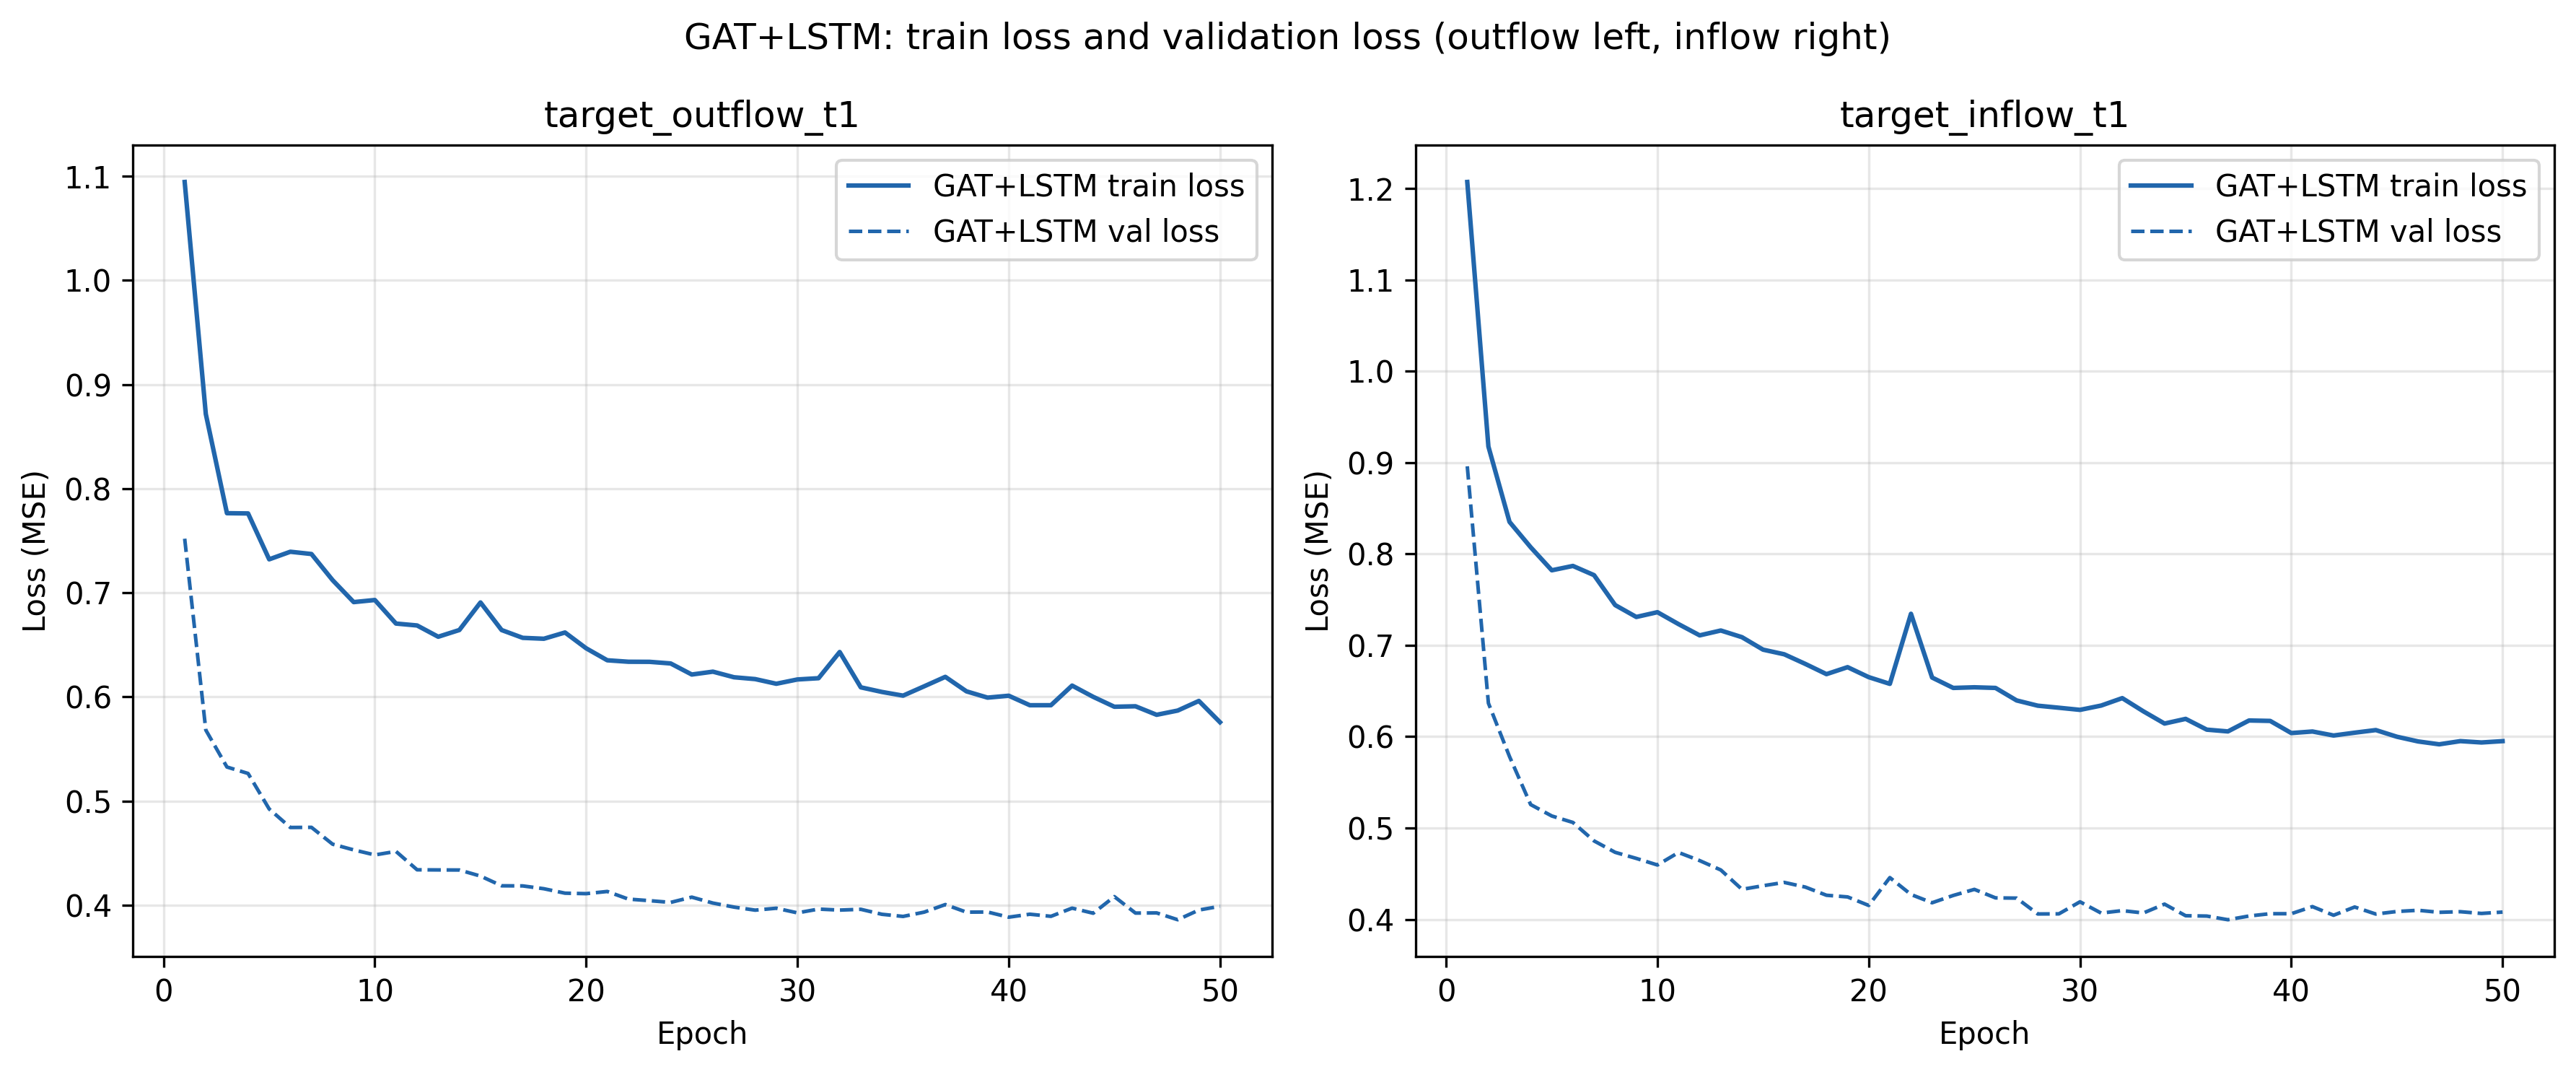

In [14]:
# --- GAT+LSTM (improved): train loss and validation loss vs epoch (outflow left, inflow right) ---
DPI = 300
COLOR_GAT = "#2166AC"
OUTFLOW_T1, INFLOW_T1 = "target_outflow_t1", "target_inflow_t1"
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=DPI)
for col, target in enumerate([OUTFLOW_T1, INFLOW_T1]):
    h = histories.get(target)
    ax = axes[col]
    if h is not None:
        ep = range(1, len(h["train_loss"]) + 1)
        ax.plot(ep, h["train_loss"], color=COLOR_GAT, label="GAT+LSTM train loss", lw=1.5)
        val_loss = h.get("val_loss", [])
        if len(val_loss) == len(ep):
            ax.plot(ep, val_loss, color=COLOR_GAT, linestyle="--", label="GAT+LSTM val loss", lw=1.2)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (MSE)")
    ax.set_title(target)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("GAT+LSTM: train loss and validation loss (outflow left, inflow right)")
plt.tight_layout()
plt.show()

GAT+LSTM: All stations — total flow by hour (Actual vs Predicted)


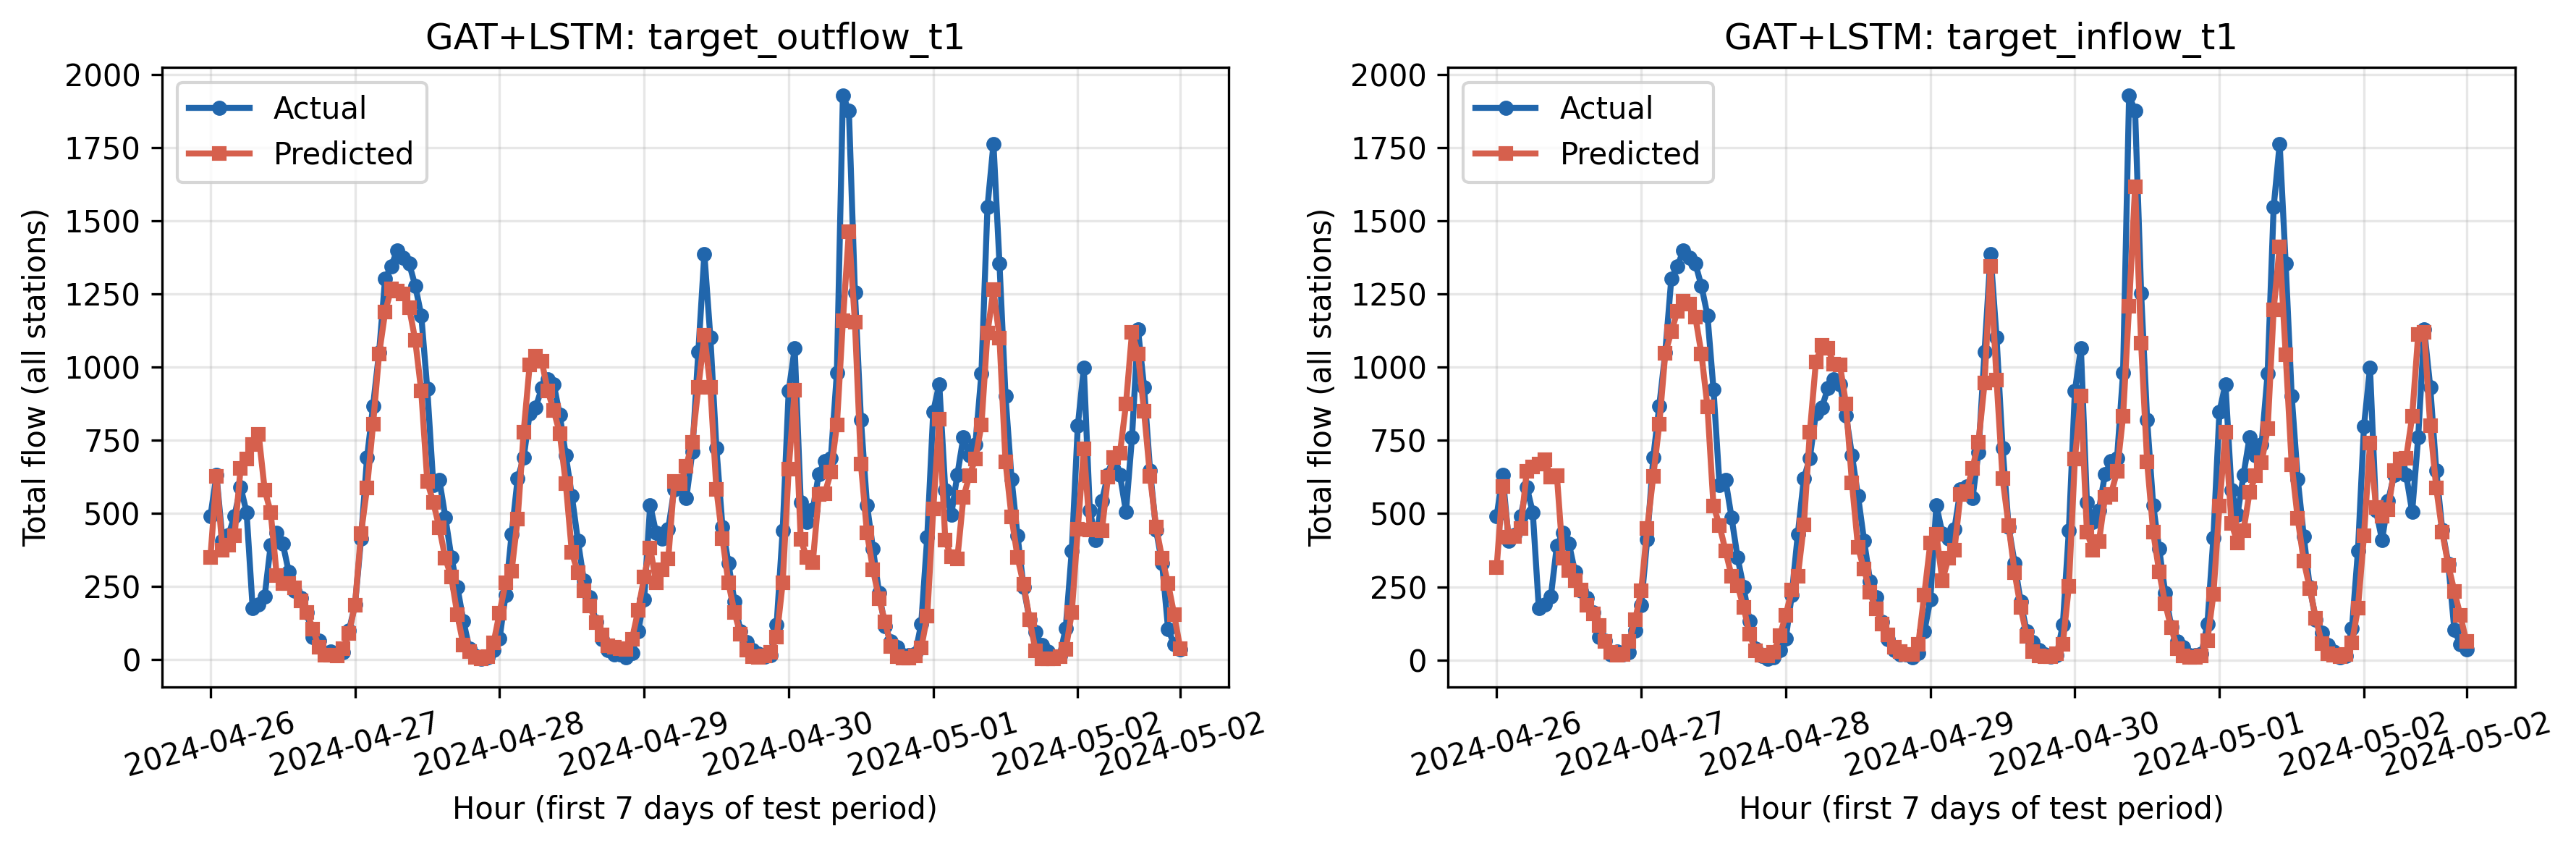

In [15]:
# --- All stations: total flow by hour — Actual vs Predicted ---
OUTFLOW_T1, INFLOW_T1 = "target_outflow_t1", "target_inflow_t1"
TARGETS_ORDER = [OUTFLOW_T1, INFLOW_T1]
COLOR_ACTUAL, COLOR_PRED = "#2166AC", "#D6604D"
print("GAT+LSTM: All stations — total flow by hour (Actual vs Predicted)")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)
for col, target in enumerate(TARGETS_ORDER):
    ax = axes[col]
    if target not in test_predictions:
        ax.set_title(f"GAT+LSTM / {target} (no data)")
        continue
    df_vis = test_predictions[target]
    actual_col = target
    first_3_dates = sorted(df_vis["date"].unique())[:7]
    df_3d = df_vis[df_vis["date"].isin(first_3_dates)]
    hourly = df_3d.groupby(["date", "hour"]).agg(actual=(actual_col, "sum"), pred=("pred", "sum")).reset_index()
    hourly = hourly.sort_values(["date", "hour"]).reset_index(drop=True)
    x = np.arange(len(hourly))
    ax.plot(x, hourly["actual"], color=COLOR_ACTUAL, label="Actual", lw=2, marker="o", markersize=4)
    ax.plot(x, hourly["pred"], color=COLOR_PRED, label="Predicted", lw=2, marker="s", markersize=4)
    tick_pos = list(range(0, len(hourly), 24))
    if len(hourly) - 1 not in tick_pos and len(hourly) > 0:
        tick_pos.append(len(hourly) - 1)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([str(hourly.iloc[i]["date"]) if i < len(hourly) else "" for i in tick_pos], rotation=15)
    ax.set_xlabel("Hour (first 7 days of test period)")
    ax.set_ylabel("Total flow (all stations)")
    ax.set_title(f"GAT+LSTM: {target}")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# --- Two-stage model: classification and regression breakdown ---
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
print("Two-stage model — test set breakdown\n")
for target in DEFAULT_TARGETS:
    df_t = test_predictions[target]
    actual = df_t[target].values
    pred   = df_t["pred"].values
    actual_bin = (actual > 0).astype(int)
    pred_bin   = (pred > 0.5).astype(int)
    print(f"[{target}]")
    print(f"  Zero rate (actual):    {1 - actual_bin.mean():.3f}")
    print(f"  Zero rate (predicted): {1 - pred_bin.mean():.3f}")
    print(f"  Accuracy:  {accuracy_score(actual_bin, pred_bin):.4f}")
    print(f"  F1:        {f1_score(actual_bin, pred_bin, zero_division=0):.4f}")
    print(f"  Precision: {precision_score(actual_bin, pred_bin, zero_division=0):.4f}")
    print(f"  Recall:    {recall_score(actual_bin, pred_bin, zero_division=0):.4f}")
    # Regression metrics on non-zero actual only
    nz = actual > 0
    if nz.sum() > 0:
        print(f"  MAE  (non-zero only): {mae(actual[nz], pred[nz]):.4f}")
        print(f"  RMSE (non-zero only): {rmse(actual[nz], pred[nz]):.4f}")
    print()


Two-stage model — test set breakdown

[target_outflow_t1]
  Zero rate (actual):    0.894
  Zero rate (predicted): 0.889
  Accuracy:  0.9373
  F1:        0.7110
  Precision: 0.6957
  Recall:    0.7270
  MAE  (non-zero only): 1.3461
  RMSE (non-zero only): 2.0712

[target_inflow_t1]
  Zero rate (actual):    0.895
  Zero rate (predicted): 0.893
  Accuracy:  0.9388
  F1:        0.7115
  Precision: 0.7044
  Recall:    0.7188
  MAE  (non-zero only): 1.3723
  RMSE (non-zero only): 2.1552

